In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
#from collections import namedtuple
import math
import ast
from scipy.stats import chisquare
from scipy import special
from scipy.optimize import minimize
import seaborn as sns
sns.set_style("whitegrid")
import shapely as shapely
from shapely.geometry import LineString

In [2]:
def SingleEscapeSort(dataframe):
    dataframe = dataframe.drop('Unnamed: 0', axis=1)
    # if b==True:
    #     dataframe = dataframe.drop('10', axis=1)
    col = dataframe.pop("NTD")
    col2 = dataframe.pop('EnergyV')
    col3 = dataframe.pop('ChannelV')
    col4 = dataframe.pop('Neighbors')
    dataframe.insert(9, col2.name, col2)
    dataframe.insert(15, col.name, col)
    dataframe.insert(10, col3.name, col3)
    dataframe.insert(14, col4.name, col4)
    
    dataframe3 = dataframe[(dataframe['Multiplicity'] == 2)]
    dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
    dataframe3['ChannelV']=dataframe3['ChannelV'].apply(ast.literal_eval)
    dataframe3['NTD']=dataframe3['NTD'].apply(ast.literal_eval)
    dataframe3['Neighbors']=dataframe3['Neighbors'].apply(ast.literal_eval)
    
    rid3 = []
    dataframe3=dataframe3.reset_index(drop=True)
    for i in range(len(dataframe3)):
        if (2070<= dataframe3.iloc[i,9][1]< 2130):
            rid3.append(i)
            
    dataframe3_2100 = dataframe3[dataframe3.index.isin(rid3)]
    dataframe3_2100=dataframe3_2100.reset_index(drop=True)
    
    return dataframe3_2100

def NTD_Sort(dataframe_1tonne_single):
    NTD_data = []
    no_NTD_data = []

    NTD_data = []

    for i in range(len(dataframe_1tonne_single)):
        for j in range(len(dataframe_1tonne_single.iloc[i,10])):
            if dataframe_1tonne_single.iloc[i,10][j] in dataframe_1tonne_single.iloc[i,17]:
                NTD_data.append(i) 

    NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(NTD_data)]
    NTD_data=NTD_data.reset_index(drop=True)

    for i in range(len(dataframe_1tonne_single)):
        for j in range(len(dataframe_1tonne_single.iloc[i,10])):
            if dataframe_1tonne_single.iloc[i,10][0] and dataframe_1tonne_single.iloc[i,10][1] not in dataframe_1tonne_single.iloc[i,17]:
                no_NTD_data.append(i) 

    no_NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(no_NTD_data)]
    no_NTD_data=no_NTD_data.reset_index(drop=True)
    
    return NTD_data, no_NTD_data

def Topology_Sort(no_NTD_data):
    F_NTD = []
    E_NTD = []
    N_NTD = []
    C_NTD = []
    O_NTD = []
    for i in range(len(no_NTD_data)):
        if no_NTD_data.iloc[i,14][0][0] == 'F':
            F_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'E':
            E_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'N':
            N_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'C':
            C_NTD.append(i)
        else:
            O_NTD.append(i)
            
    F_NTD = no_NTD_data[no_NTD_data.index.isin(F_NTD)]
    F_NTD=F_NTD.reset_index(drop=True)
    
    E_NTD = no_NTD_data[no_NTD_data.index.isin(E_NTD)]
    E_NTD=E_NTD.reset_index(drop=True)
    
    N_NTD = no_NTD_data[no_NTD_data.index.isin(N_NTD)]
    N_NTD=N_NTD.reset_index(drop=True)
    
    C_NTD = no_NTD_data[no_NTD_data.index.isin(C_NTD)]
    C_NTD=C_NTD.reset_index(drop=True)
    
    return F_NTD, E_NTD, C_NTD, N_NTD

def PrimarySecondarySplit(dataframe_1tonne_double):
    total_2100 = []
    total_511 = []

    for i in range(len(dataframe_1tonne_double)):
        total_511.append(dataframe_1tonne_double.iloc[i,9][0])
        total_2100.append(dataframe_1tonne_double.iloc[i,9][1])
        
    return np.asarray(total_2100), np.asarray(total_511)

In [3]:
dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
dataframe_single = SingleEscapeSort(dataframe)

NTD_single, no_NTD_single = NTD_Sort(dataframe_single)
F_NTD, E_NTD, C_NTD, N_NTD= Topology_Sort(NTD_single)
F, E, C, N= Topology_Sort(no_NTD_single)

NTD_2100, NTD_511 = PrimarySecondarySplit(NTD_single)

/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_64072/3028205152.py:1: DtypeWarning: Columns (27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_64072/553640031.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_64072/553640031.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

In [42]:
def NormGuassianStepLinear(x,mu,sigma, A,f,d, E0, E1):
    Ec = (E0+E1)/2
    p = (1+A*(x-Ec))/(E1-E0)
    step_norm_const = ((mu-E0)*special.erfc((E0-mu)/np.sqrt(2*np.pi*sigma**2))+(E1-mu)*special.erfc((E1-mu)/np.sqrt(2*np.pi*sigma**2))+np.sqrt(2*sigma**2)*(np.exp(-(mu-E0)**2/(2*np.pi*sigma**2))-np.exp(-(mu-E1)**2/(2*np.pi*sigma**2))))
    return (1-f-d)*((np.exp(-(x-mu)**2/(2*sigma**2)))/np.sqrt(2*np.pi*sigma**2))+f*p + (d*special.erfc((x-mu)/np.sqrt(2*np.pi*sigma**2)))/step_norm_const

def NegLogLGuassStepLinear(params,data):
    mu,sigma, A, f, d = params
    E0 = min(data)
    E1 = max(data)
    x = NormGuassianStepLinear(data,mu,sigma,A,f, d, E0, E1)
    x = x[x > 0]
    LogL = np.sum(np.log(x))
    return -2*LogL

def MinimizeNegLogLGuassStepLinear(data, initial_params):
    E0 = min(data)
    E1 = max(data)
    Ec = (E0+E1)/2
    bound_A = 1/(Ec-E0)
    result = minimize(NegLogLGuassStepLinear, initial_params, args=(data),
                      method='Nelder-Mead',bounds=[(0, None), (0, None), (-bound_A, bound_A),  (0,1), (0,1)])
    return result.x

def Chi2(data, mu, sigma,A,f, d):
    bin_num = int(max(data) - min(data))
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]
        
    E0 = min(data)
    E1 = max(data)

    fitted_pdf = NormGuassianStepLinear(filtered_bin_centers, mu, sigma, A, f,d, E0, E1)*len(data)*bin_width

    chi2 = np.sum((filtered_hist-fitted_pdf)**2/fitted_pdf)
    
    return chi2

In [41]:
data = np.asarray(NTD_2100)
mu = 2104.4138503844847
sigma = 3.0219099367951583
A = 0.033
f = 0.1
d = 0.1
initial_parms = [mu, sigma,A, f,d]
mu_fit, sigma_fit,A_fit,f_fit, d_fit= MinimizeNegLogLGuassStepLinear(data, initial_parms)
# print(f"Fitted parameters: {fitted_params}")
x_values = np.linspace(min(data), max(data), 1000)
bin_num = int(max(data) - min(data))
bin_width = (max(x_values) - min(x_values))/bin_num

fitted_pdf = NormGuassianStepLinear(x_values, mu_fit, sigma_fit, A_fit, f_fit, d_fit, min(data), max(data))*len(data)*bin_width

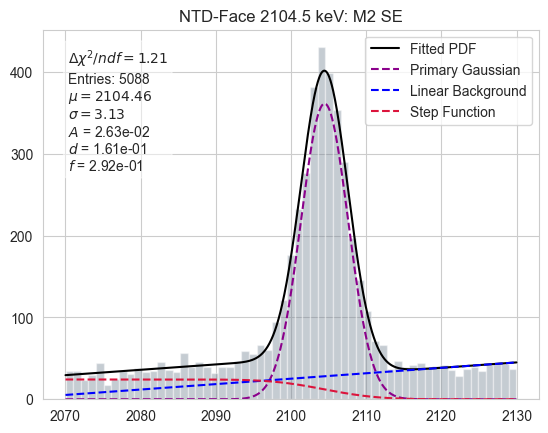

In [44]:
fig, ax = plt.subplots()
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
textF = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(data, mu_fit, sigma_fit, A_fit, f_fit, d_fit)/((int(max(data) - min(data)))-5), ),
    'Entries: ' + (str(len(data))),
    r'$\mu=%.2f$' % (mu_fit, ),
    r'$\sigma=%.2f$' % (sigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(A_fit, precision = 2), ),
    r'$d$ = ' + str(np.format_float_scientific(d_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(f_fit, precision = 2), )))

ax.plot(x_values, fitted_pdf,label='Fitted PDF', color='black')
ax.plot(x_values, (1-f_fit-d_fit)*((np.exp(-(x_values-mu_fit)**2/(2*sigma_fit**2)))/np.sqrt(2*np.pi*sigma_fit**2))*len(data)*bin_width, label = 'Primary Gaussian', linestyle='--', color='darkmagenta')
ax.plot(x_values, (f_fit*(1+A_fit*(x_values-((min(data)+max(data))/2)))/(max(data)-min(data)))*len(data)*bin_width, label = 'Linear Background', linestyle='--', color='blue')
ax.plot(x_values, ((d_fit*special.erfc((x_values-mu_fit)/np.sqrt(2*np.pi*sigma_fit**2)))/((mu_fit-min(data))*special.erfc((min(data)-mu_fit)/np.sqrt(2*np.pi*sigma_fit**2))+(max(data)-mu_fit)*special.erfc((max(data)-mu_fit)/np.sqrt(2*np.pi*sigma_fit**2))+np.sqrt(2*sigma_fit**2)*(np.exp(-(mu_fit-min(data))**2/(2*np.pi*sigma_fit**2))-np.exp(-(mu_fit-max(data))**2/(2*np.pi*sigma_fit**2)))))*len(data)*bin_width, label='Step Function', linestyle = '--', color='crimson')

ax.hist(data, bins = (int(max(data) - min(data))) , color='slategray', alpha=0.4)
ax.text(0.05, 0.95, textF, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax.set_title('NTD-Face 2104.5 keV: M2 SE')
ax.legend()

In [45]:
noNTD_2100, noNTD_511 = PrimarySecondarySplit(no_NTD_single)

mu = 2104.158147262019
sigma = 2.897366961722745
A = 0.033
f = 0.47246349270117927
d = 0.09977305996556526

initial_parms = [mu, sigma,A, f,d]
mu_fitNoNTD, sigma_fitNoNTD, A_fitNoNTD, f_fitNoNTD, d_fitNoNTD = MinimizeNegLogLGuassStepLinear(noNTD_2100, initial_parms)
# print(f"Fitted parameters: {fitted_params}")
x_valuesNoNTD = np.linspace(min(noNTD_2100), max(noNTD_2100), 1000)
bin_num = ((int(max(noNTD_2100) - min(noNTD_2100))))
bin_width = (max(x_values) - min(x_values))/bin_num

fitted_pdfNoNTD = NormGuassianStepLinear(x_values, mu_fitNoNTD,sigma_fitNoNTD,A_fitNoNTD, f_fitNoNTD,d_fitNoNTD , min(x_values), max(x_values))*len(noNTD_2100)*bin_width

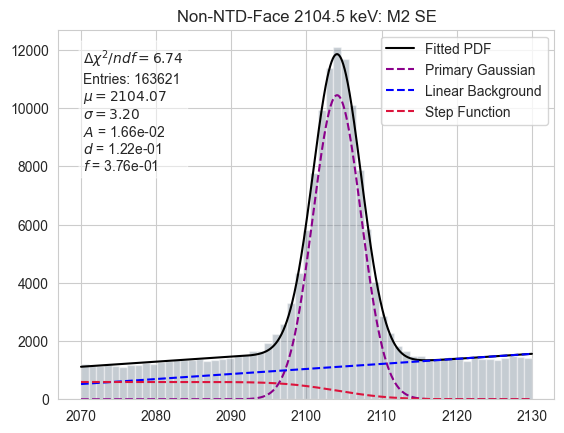

In [46]:
fig, ax = plt.subplots()
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
textNoNTD = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(noNTD_2100, mu_fitNoNTD, sigma_fitNoNTD, A_fitNoNTD, f_fitNoNTD, d_fitNoNTD)/((int(max(noNTD_2100) - min(noNTD_2100)))-5), ),
    'Entries: ' + (str(len(noNTD_2100))),
    r'$\mu=%.2f$' % (mu_fitNoNTD, ),
    r'$\sigma=%.2f$' % (sigma_fitNoNTD, ),
    r'$A$ = ' + str(np.format_float_scientific(A_fitNoNTD, precision = 2), ),
    r'$d$ = ' + str(np.format_float_scientific(d_fitNoNTD, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(f_fitNoNTD, precision = 2), )))

ax.plot(x_valuesNoNTD, fitted_pdfNoNTD,label='Fitted PDF', color='black')
ax.plot(x_valuesNoNTD, (1-f_fitNoNTD-d_fitNoNTD)*((np.exp(-(x_valuesNoNTD-mu_fitNoNTD)**2/(2*sigma_fitNoNTD**2)))/np.sqrt(2*np.pi*sigma_fitNoNTD**2))*len(noNTD_2100)*bin_width, label = 'Primary Gaussian', linestyle='--', color='darkmagenta')
ax.plot(x_valuesNoNTD, (f_fitNoNTD*(1+A_fitNoNTD*(x_valuesNoNTD-((min(noNTD_2100)+max(noNTD_2100))/2)))/(max(noNTD_2100)-min(noNTD_2100)))*len(noNTD_2100)*bin_width, label = 'Linear Background', linestyle='--', color='blue')
ax.plot(x_valuesNoNTD, ((d_fitNoNTD*special.erfc((x_valuesNoNTD-mu_fitNoNTD)/np.sqrt(2*np.pi*sigma_fitNoNTD**2)))/((mu_fitNoNTD-min(noNTD_2100))*special.erfc((min(noNTD_2100)-mu_fitNoNTD)/np.sqrt(2*np.pi*sigma_fitNoNTD**2))+(max(noNTD_2100)-mu_fitNoNTD)*special.erfc((max(noNTD_2100)-mu_fitNoNTD)/np.sqrt(2*np.pi*sigma_fitNoNTD**2))+np.sqrt(2*sigma_fitNoNTD**2)*(np.exp(-(mu_fitNoNTD-min(noNTD_2100))**2/(2*np.pi*sigma_fitNoNTD**2))-np.exp(-(mu_fitNoNTD-max(noNTD_2100))**2/(2*np.pi*sigma_fitNoNTD**2)))))*len(noNTD_2100)*bin_width, label='Step Function', linestyle = '--', color='crimson')

ax.hist(noNTD_2100, bins = (int(max(noNTD_2100) - min(noNTD_2100))) , color='slategray', alpha=0.4)
ax.text(0.05, 0.95, textNoNTD, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax.set_title('Non-NTD-Face 2104.5 keV: M2 SE')
ax.legend()

In [34]:
F_2100, F_511 = PrimarySecondarySplit(F)
C_2100, C_511 = PrimarySecondarySplit(C)
N_2100, N_511 = PrimarySecondarySplit(N)
E_2100, E_511 = PrimarySecondarySplit(E)

F_initial_2100= []
C_initial_2100 = []
N_initial_2100 = []
E_initial_2100 = []

Cmu_fit, Csigma_fit, CA_fit, Cf_fit, Cd_fit = MinimizeNegLogLGuassStepLinear(C_2100, initial_parms)
Emu_fit, Esigma_fit, EA_fit, Ef_fit, Ed_fit = MinimizeNegLogLGuassStepLinear(E_2100, initial_parms)
Nmu_fit, Nsigma_fit, NA_fit, Nf_fit, Nd_fit = MinimizeNegLogLGuassStepLinear(N_2100, initial_parms)
Fmu_fit, Fsigma_fit, FA_fit, Ff_fit, Fd_fit = MinimizeNegLogLGuassStepLinear(F_2100, initial_parms)

In [50]:
def Graph(data, mu_fit, sigma_fit, A_fit, f_fit, d_fit):
    x_values = np.linspace(min(data), max(data), 1000)
    bin_num = ((int(max(data) - min(data))))
    bin_width = (max(x_values) - min(x_values))/bin_num
    
    fitted_pdf = NormGuassianStepLinear(x_values, mu_fit, sigma_fit, A_fit, f_fit, d_fit, min(data), max(data))*len(data)*bin_width
    guass = (1-f_fit-d_fit)*((np.exp(-(x_values-mu_fit)**2/(2*sigma_fit**2)))/np.sqrt(2*np.pi*sigma_fit**2))*len(data)*bin_width
    linear_bkg = (f_fit*(1+A_fit*(x_values-((min(data)+max(data))/2)))/(max(data)-min(data)))*len(data)*bin_width
    step_func = ((d_fit*special.erfc((x_values-mu_fit)/np.sqrt(2*np.pi*sigma_fit**2)))/((mu_fit-min(data))*special.erfc((min(data)-mu_fit)/np.sqrt(2*np.pi*sigma_fit**2))+(max(data)-mu_fit)*special.erfc((max(data)-mu_fit)/np.sqrt(2*np.pi*sigma_fit**2))+np.sqrt(2*sigma_fit**2)*(np.exp(-(mu_fit-min(data))**2/(2*np.pi*sigma_fit**2))-np.exp(-(mu_fit-max(data))**2/(2*np.pi*sigma_fit**2)))))*len(data)*bin_width
    
    return x_values, fitted_pdf, guass, step_func, linear_bkg

Fx, F_fit, Fguass, Fstep, Flinear = Graph(F_2100, Fmu_fit, Fsigma_fit, FA_fit, Ff_fit, Fd_fit)
Cx, C_fit, Cguass, Cstep, Clinear = Graph(C_2100, Cmu_fit, Csigma_fit, CA_fit, Cf_fit,Cd_fit)
Nx, N_fit, Nguass, Nstep, Nlinear = Graph(N_2100, Nmu_fit, Nsigma_fit, NA_fit, Nf_fit, Nd_fit)
Ex, E_fit, Eguass, Estep, Elinear = Graph(E_2100, Emu_fit, Esigma_fit, EA_fit, Ef_fit, Ed_fit)

In [49]:
Fchi2 = Chi2(F_2100, Fmu_fit, Fsigma_fit, FA_fit, Ff_fit, Fd_fit)
Cchi2 = Chi2(C_2100, Cmu_fit, Csigma_fit, CA_fit, Cf_fit, Cd_fit)
Nchi2 = Chi2(N_2100, Nmu_fit, Nsigma_fit, NA_fit, Nf_fit, Nd_fit)
Echi2 = Chi2(E_2100, Emu_fit, Esigma_fit, EA_fit, Ef_fit, Ed_fit)

Text(0.5, 1.0, 'E')

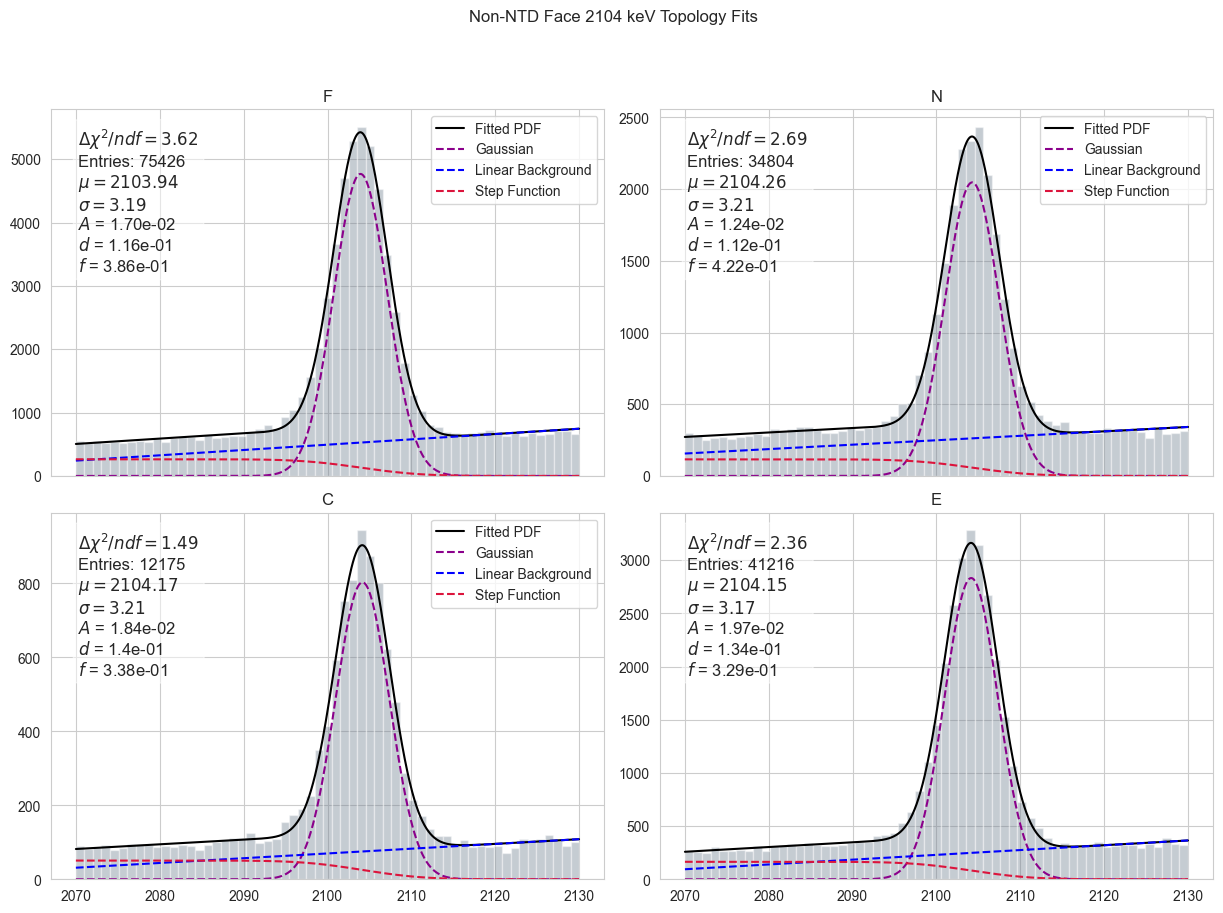

In [51]:
fig, ax = plt.subplots(2,2, sharex='col',  figsize=(15, 10))
# fig.text(0.04, 0.5, 'Energy (keV)', va='center', rotation = 'vertical')
# fig.text(0.5, 0.04, 'Counts', ha='center')
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
fig.suptitle('Non-NTD Face 2104 keV Topology Fits')
plt.subplots_adjust(wspace=0.1, hspace=0.1)

textF = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Fchi2/((int(max(F_2100) - min(F_2100)))-5), ),
    'Entries: ' + (str(len(F_2100))),
    r'$\mu=%.2f$' % (Fmu_fit, ),
    r'$\sigma=%.2f$' % (Fsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(FA_fit, precision = 2), ),
    r'$d$ = ' + str(np.format_float_scientific(Fd_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(Ff_fit, precision = 2), )))

ax[0,0].plot(Fx, F_fit,label='Fitted PDF', color='black')
ax[0,0].plot(Fx, Fguass, label = 'Gaussian', linestyle='--', color='darkmagenta')
ax[0,0].plot(Fx, Flinear, label = 'Linear Background', linestyle='--', color='blue')
ax[0,0].plot(Fx, Fstep, label='Step Function', linestyle = '--', color='crimson')

ax[0,0].hist(F_2100, bins = ((int(max(F_2100) - min(F_2100)))) , color='slategray', alpha=0.4)
ax[0,0].text(0.05, 0.95, textF, transform=ax[0,0].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[0,0].set_title('F')
ax[0,0].legend()
###########

textC = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Cchi2/((int(max(C_2100) - min(C_2100)))-5), ),
    'Entries: ' + (str(len(C_2100))),
    r'$\mu=%.2f$' % (Cmu_fit, ),
    r'$\sigma=%.2f$' % (Csigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(CA_fit, precision = 2), ),
    r'$d$ = ' + str(np.format_float_scientific(Cd_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(Cf_fit, precision = 2), )))

ax[1,0].plot(Cx, C_fit,label='Fitted PDF', color='black')
ax[1,0].plot(Cx, Cguass, label = 'Gaussian', linestyle='--', color='darkmagenta')
ax[1,0].plot(Cx, Clinear, label = 'Linear Background', linestyle='--', color='blue')
ax[1,0].plot(Cx, Cstep, label='Step Function', linestyle = '--', color='crimson')


ax[1,0].hist(C_2100, bins = (int(max(C_2100) - min(C_2100))), color='slategray', alpha=0.4)
ax[1,0].text(0.05, 0.95, textC, transform=ax[1,0].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[1,0].set_title('C')
ax[1,0].legend()
#########

textN = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Nchi2/((int(max(N_2100) - min(N_2100)))-5), ),
    'Entries: ' + (str(len(N_2100))),
    r'$\mu=%.2f$' % (Nmu_fit, ),
    r'$\sigma=%.2f$' % (Nsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(NA_fit, precision = 2), ),
    r'$d$ = ' + str(np.format_float_scientific(Nd_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(Nf_fit, precision = 2), )))

ax[0,1].plot(Nx, N_fit,label='Fitted PDF', color='black')
ax[0,1].plot(Nx, Nguass, label = 'Gaussian', linestyle='--', color='darkmagenta')
ax[0,1].plot(Nx, Nlinear, label = 'Linear Background', linestyle='--', color='blue')
ax[0,1].plot(Nx, Nstep, label='Step Function', linestyle = '--', color='crimson')

ax[0,1].hist(N_2100, bins = (int(max(N_2100) - min(N_2100))), color='slategrey', alpha=0.4)
ax[0,1].text(0.05, 0.95, textN, transform=ax[0,1].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[0,1].set_title('N')
ax[0,1].legend()
########

textE = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Echi2/((int(max(E_2100) - min(E_2100)))-5), ),
    'Entries: ' + (str(len(E_2100))),
    r'$\mu=%.2f$' % (Emu_fit, ),
    r'$\sigma=%.2f$' % (Esigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(EA_fit, precision = 2), ),
    r'$d$ = ' + str(np.format_float_scientific(Ed_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(Ef_fit, precision = 2), )))

ax[1,1].plot(Ex, E_fit,label='E Fit', color='black')
ax[1,1].plot(Ex, Eguass, label = 'Gaussian', linestyle='--', color='darkmagenta')
ax[1,1].plot(Ex, Elinear, label = 'Linear Background', linestyle='--', color='blue')
ax[1,1].plot(Ex, Estep, label='Step Function', linestyle = '--', color='crimson')

ax[1,1].hist(E_2100, bins = (int(max(E_2100) - min(E_2100))), color='slategrey', alpha=0.4)
ax[1,1].text(0.05, 0.95, textE, transform=ax[1,1].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[1,1].set_title('E')